# Simple Linear Regression

### Student name: Baqar Ali

### Teacher name: Sir Zafar Iqbal

## Problem Statement
In this project, I will build a Simple Linear Regression model to predict the tip amount based on the total bill amount.


In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [24]:
df = sns.load_dataset("tips")

In [25]:
print(f"Our dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Our dataset has 244 rows and 7 columns


for Simple Linear Regression we need only two columns(total_bill and tip)

## EDA 

In [26]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [28]:
df=df.drop(columns=["sex","smoker","day","size","time"])
df.head()

,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61


## Data Cleaning

In [29]:
df.isnull().sum()

total_bill    0
tip           0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(2)

In [31]:
df=df.drop_duplicates()

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.describe()

,total_bill,tip
count,242.000000,242.000000
mean,19.838678,3.006529
std,8.920123,1.386363
min,3.070000,1.000000
25%,13.375000,2.000000
50%,17.815000,2.960000
75%,24.222500,3.587500
max,50.810000,10.000000


<Axes: xlabel='total_bill', ylabel='Count'>

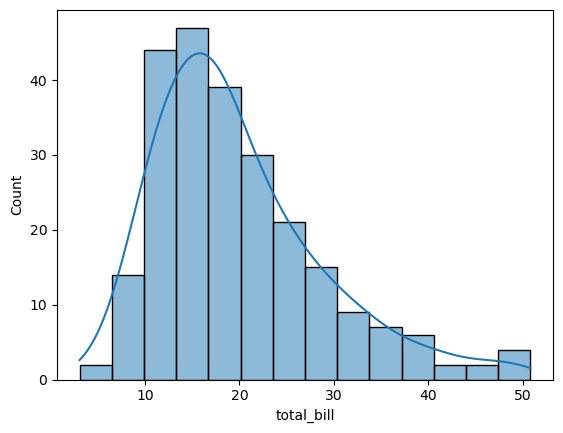

In [34]:
# Distribution of total_bill
#plt.title(" Distribution of total_bill")
sns.histplot(x=df["total_bill"],kde=True)

<Axes: xlabel='total_bill'>

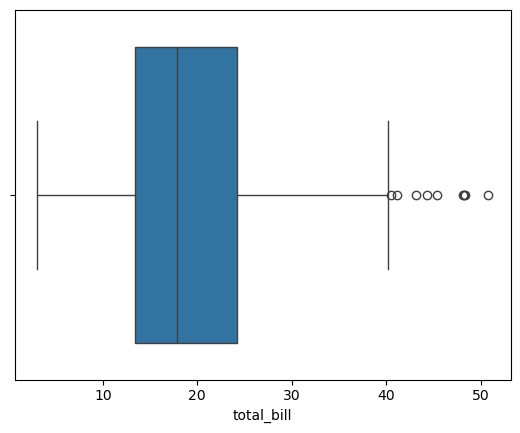

In [35]:
sns.boxplot(x=df["total_bill"])

In [36]:
Q1 = df["total_bill"].quantile(0.25)
Q3 = df["total_bill"].quantile(0.75)
IQR = Q3-Q1
upper_bound = IQR*1.5+Q3

In [37]:
len(df[df["total_bill"]>upper_bound])

9

Our dataset has 9 outliers

In [38]:
df[df["total_bill"]>upper_bound].head(9).sort_values(by="total_bill", ascending=False)

,total_bill,tip
170,50.81,10.00
212,48.33,9.00
59,48.27,6.73
156,48.17,5.00
182,45.35,3.50
102,44.30,2.50
197,43.11,5.00
142,41.19,5.00
184,40.55,3.00


Hence we should not remove the ouliters here becaue the total_bill range is 50 - 40 which is possilbe not a error

<Axes: xlabel='total_bill', ylabel='tip'>

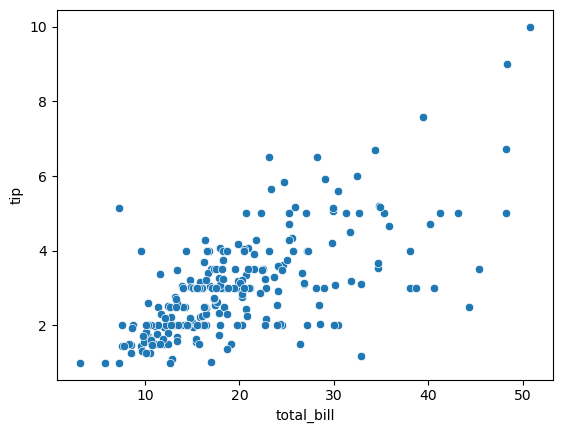

In [39]:
sns.scatterplot(x=df["total_bill"],y=df["tip"])

Relationship between target and feature is also linear

In [40]:
X=df[["total_bill"]]
y=df["tip"]
X_train,X_test,y_train,y_test = train_test_split(X,y, train_size=0.8,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)


In [41]:
result=pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred,
    "Error":y_test-y_pred
})

In [42]:
result

,Actual,Predicted,Error
24,3.18,2.990859,0.189141
6,2.00,1.863621,0.136379
152,2.74,2.729707,0.010293
211,5.16,3.610074,1.549926
239,5.92,3.930393,1.989607
200,4.00,2.877625,1.122375
191,4.19,2.989839,1.200161
150,2.50,2.404287,0.095713
9,3.23,2.476716,0.753284
113,2.55,3.412170,-0.862170


<Axes: xlabel='Actual', ylabel='Predicted'>

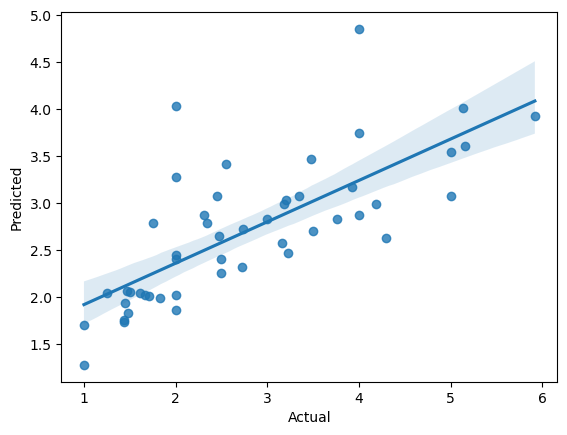

In [43]:
sns.regplot(x=result["Actual"],y=result["Predicted"])

In [44]:
print("r2_score: ",r2_score(y_test,y_pred))

r2_score:  0.5244263312460902


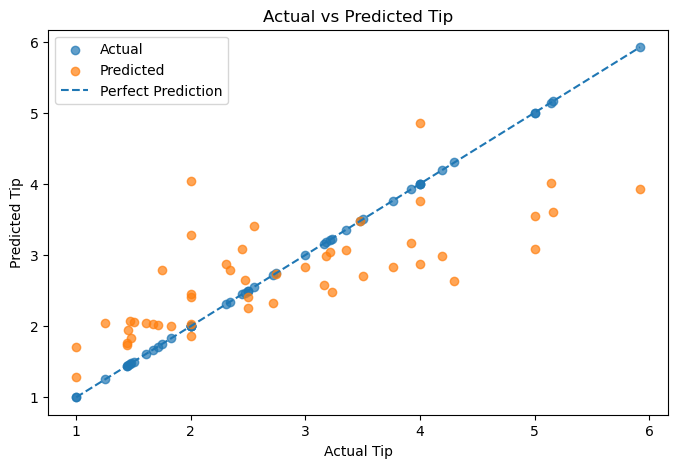

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Actual values
plt.scatter(y_test, y_test, label="Actual", alpha=0.7)

# Predicted values
plt.scatter(y_test, y_pred, label="Predicted", alpha=0.7)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--",
         label="Perfect Prediction")

plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title("Actual vs Predicted Tip")

plt.legend()
plt.show()